--- DataFrame (перші 5 рядків) ---
   день  вихідний  температура  продажі
0     1     False         -0.5       36
1     2     False          1.1       30
2     3     False          0.3       30
3     4     False         -1.3       37
4     5     False         -3.7       32


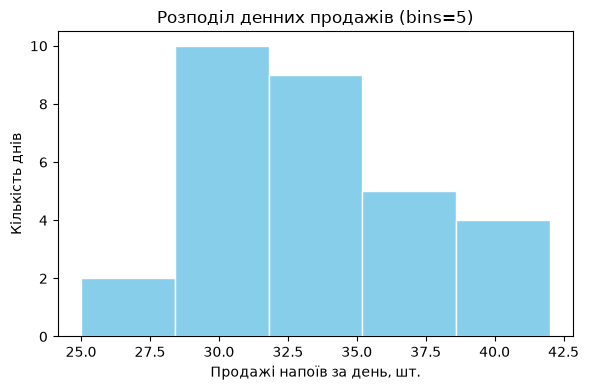

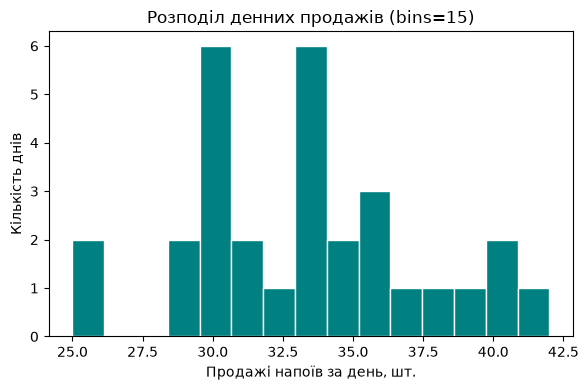

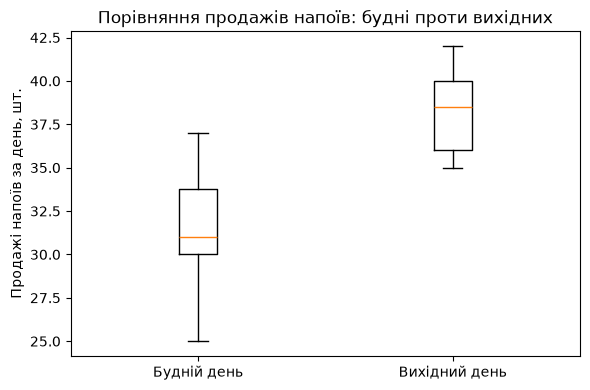

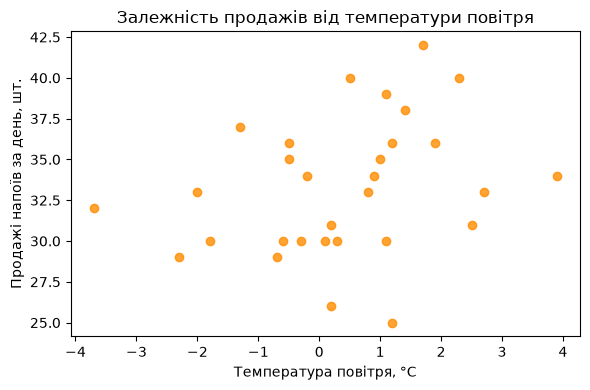

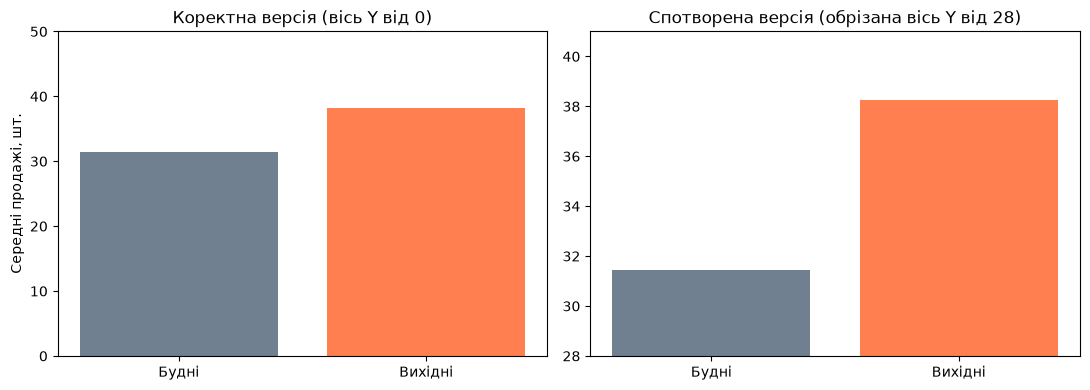

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# ЗАВДАННЯ 1.(Варіант 6: Чернігів)
# ==============================================================================
VARIANT = 6
BASE_SALES = 32
BASE_TEMP = 0

# Фіксація генератора випадкових чисел номером варіанта
np.random.seed(VARIANT)

days = np.arange(1, 31)

# Кожен 6-й та 7-й день тижня — вихідні (булеве значення)
weekend = np.isin(days % 7, [6, 0])

# Температура: базова (0 °C) ± 3°C
temperature = np.round(BASE_TEMP + np.random.normal(0, 1.5, size=30), 1)

# Продажі: базові (32 шт) + збільшення на вихідних (~20%) + температурний шум
weekend_boost = weekend * np.random.uniform(0.15, 0.25) * BASE_SALES
noise = np.random.normal(0, 3, size=30)
sales = np.round(BASE_SALES + weekend_boost + noise).astype(int)

# Формування DataFrame
kiosk_df = pd.DataFrame({
    "день": days,
    "вихідний": weekend,
    "температура": temperature,
    "продажі": sales
})

print("--- DataFrame (перші 5 рядків) ---")
print(kiosk_df.head())


# ==============================================================================
# ЗАВДАННЯ 2. Гістограма
# ==============================================================================
# Побудова з bins = 5
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(kiosk_df["продажі"], bins=5, edgecolor="white", color="skyblue")
ax.set_xlabel("Продажі напоїв за день, шт.")
ax.set_ylabel("Кількість днів")
ax.set_title("Розподіл денних продажів (bins=5)")
plt.tight_layout()
plt.show()

# Побудова з bins = 15
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(kiosk_df["продажі"], bins=15, edgecolor="white", color="teal")
ax.set_xlabel("Продажі напоїв за день, шт.")
ax.set_ylabel("Кількість днів")
ax.set_title("Розподіл денних продажів (bins=15)")
plt.tight_layout()
plt.show()

"""
ПОЯСНЕННЯ ДО ЗАВДАННЯ 2:
Для вибірки з 30 значень більш змістовну картину дає варіант із bins = 5.
При bins = 15 спостерігається занадто сильна фрагментація інтервалів (багато 
порожніх бінів або інтервалів із 1-2 значеннями), що створює візуальний "шум" 
і приховує загальну форму розподілу. Натомість bins = 5 чітко показує 
двомодальність / виражений пік та загальний розкид продажів.
"""


# ==============================================================================
# ЗАВДАННЯ 3. Boxplot (Будні проти Вихідних)
# ==============================================================================
fig, ax = plt.subplots(figsize=(6, 4))

groups = [
    kiosk_df.loc[~kiosk_df["вихідний"], "продажі"],
    kiosk_df.loc[kiosk_df["вихідний"], "продажі"]
]

ax.boxplot(groups, tick_labels=["Будній день", "Вихідний день"])
ax.set_ylabel("Продажі напоїв за день, шт.")
ax.set_title("Порівняння продажів напоїв: будні проти вихідних")
plt.tight_layout()
plt.show()

"""
ОПИС ДО ЗАВДАННЯ 3:
Медіана продажів у вихідні дні є помітно вищою (приблизно 38-40 шт.), ніж у 
будні (приблизно 31-32 шт.). Міжквартильний розкид (IQR) у вихідні також трохи 
ширший. Це повністю узгоджується з умовами Завдання 1, де до продажів у вихідні 
додавалася надбавка в розмірі 15–25%.
"""


# ==============================================================================
# ЗАВДАННЯ 4. Діаграма розсіювання (Scatter plot)
# ==============================================================================
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(kiosk_df["температура"], kiosk_df["продажі"], color="darkorange", alpha=0.8)
ax.set_xlabel("Температура повітря, °C")
ax.set_ylabel("Продажі напоїв за день, шт.")
ax.set_title("Залежність продажів від температури повітря")
plt.tight_layout()
plt.show()

"""
ОПИС ДО ЗАВДАННЯ 4:
На графіку спостерігається слабкий/помірний позитивний зв'язок (або відсутність 
вираженого тренду через невеликий розкид температури ±3°C навколо 0°C). 
Для кіоску гарячих напоїв у зимовий період (близько 0°C) це є очікуваним, 
оскільки коливання температури в районі нуля суттєво не змінюють попит на 
зігріваючі напої, на відміну від літнього періоду для прохолоджувальних напоїв.
"""


# ==============================================================================
# ЗАВДАННЯ 5. Навмисно спотворений графік (Порівняння поруч)
# ==============================================================================
# Розрахунок середніх продажів для стовпчикової діаграми
weekday_mean = kiosk_df.loc[~kiosk_df["вихідний"], "продажі"].mean()
weekend_mean = kiosk_df.loc[kiosk_df["вихідний"], "продажі"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# 1. Коректний графік (початок оси Y з 0)
ax1.bar(["Будні", "Вихідні"], [weekday_mean, weekend_mean], color=["slategray", "coral"])
ax1.set_ylim(0, 50)
ax1.set_ylabel("Середні продажі, шт.")
ax1.set_title("Коректна версія (вісь Y від 0)")

# 2. Спотворений графік (обрізана вісь Y)
ax2.bar(["Будні", "Вихідні"], [weekday_mean, weekend_mean], color=["slategray", "coral"])
ax2.set_ylim(28, 41)  # Обрізаємо нижню частину стовпчиків
ax2.set_title("Спотворена версія (обрізана вісь Y від 28)")

plt.tight_layout()
plt.show()

#ПОЯСНЕННЯ ДО ЗАВДАННЯ 5:
#Застосовано спотворення "Truncated Y-axis" (обрізана вісь Y). 
#На спотвореному графіку вісь Y починається з 28 замість 0. Через це стовпчик 
#продажів у вихідні здається приблизно в 3-4 рази вищим за стовпчик будніх днів, 
#хоча фактична різниця становить лише близько 20-25% (приблизно 31.5 проти 39 шт.). 
#Це візуально вводить спостерігача в оману, штучно перебільшуючи реальний ефект.
